In [1]:
!pip install gymnasium

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

In [3]:
class DynamicPricingEnv(gym.Env):

    def __init__(self):
        super().__init__()

        # Actions
        # 0 = Decrease Price
        # 1 = Keep Price
        # 2 = Increase Price

        self.action_space = spaces.Discrete(3)

        # State:
        # Demand
        # Inventory
        # Competitor Price
        # Current Price

        self.observation_space = spaces.Box(
            low=0,
            high=100,
            shape=(4,),
            dtype=np.float32
        )

        self.state = np.array([50, 50, 50, 50], dtype=np.float32)

In [4]:
    def reset(self, seed=None, options=None):

        self.state = np.array([50,50,50,50],dtype=np.float32)

        return self.state, {}

In [5]:
    def step(self, action):

        reward = np.random.randint(1,10)

        self.state = np.random.randint(
            0,
            100,
            size=(4,)
        ).astype(np.float32)

        terminated = False
        truncated = False

        return self.state, reward, terminated, truncated, {}

In [6]:
env = DynamicPricingEnv()

In [7]:
print("Action Space")
print(env.action_space)

Action Space
Discrete(3)


In [8]:
print("Observation Space")
print(env.observation_space)

Observation Space
Box(0.0, 100.0, (4,), float32)


In [23]:
def reset(self, seed=None, options=None):
    self.state = np.array([50, 50, 50, 50], dtype=np.float32)
    return self.state, {}

In [24]:
def step(self, action):

    reward = np.random.randint(1, 10)

    self.state = np.random.randint(
        0, 100, size=(4,)
    ).astype(np.float32)

    terminated = False
    truncated = False

    return self.state, reward, terminated, truncated, {}

In [25]:
def calculate_reward(demand, price):

    if demand >= 70:
        reward = price * 0.10
    else:
        reward = price * 0.05

    return reward

In [13]:
actions = {
    0: "Decrease Price",
    1: "Keep Price",
    2: "Increase Price"
}

print(actions)

{0: 'Decrease Price', 1: 'Keep Price', 2: 'Increase Price'}


In [26]:
action = 2

# Temporary definition of state for this cell to run independently
# The actual state should come from the env.reset() or env.step()
state = {
    "Demand": 75,
    "Inventory": 60,
    "Competitor_Price": 1200,
    "Current_Price": 1000
}

current_price = state["Current_Price"]

if action == 0:
    current_price -= 100

elif action == 1:
    current_price = current_price

elif action == 2:
    current_price += 100

print("Updated Price:", current_price)

Updated Price: 1100


In [27]:
reward = calculate_reward(
    state["Demand"],
    current_price
)

print("Reward:", reward)

Reward: 110.0


In [28]:
state = {
    "Demand": 75,
    "Inventory": 60,
    "Competitor_Price": 1200,
    "Current_Price": 1000
}

action = env.action_space.sample()

print("Action:", actions[action])

reward = calculate_reward(
    state["Demand"],
    state["Current_Price"]
)

print("Reward:", reward)

Action: Keep Price
Reward: 100.0


In [29]:
for episode in range(10):

    demand = np.random.randint(30,100)

    price = np.random.randint(800,1500)

    reward = calculate_reward(
        demand,
        price
    )

    print(
        f"Episode {episode+1}"
    )

    print(
        "Demand:",
        demand
    )

    print(
        "Price:",
        price
    )

    print(
        "Reward:",
        reward
    )

    print("-------------------")

Episode 1
Demand: 55
Price: 920
Reward: 46.0
-------------------
Episode 2
Demand: 76
Price: 1356
Reward: 135.6
-------------------
Episode 3
Demand: 96
Price: 1393
Reward: 139.3
-------------------
Episode 4
Demand: 60
Price: 1338
Reward: 66.9
-------------------
Episode 5
Demand: 54
Price: 1396
Reward: 69.8
-------------------
Episode 6
Demand: 64
Price: 902
Reward: 45.1
-------------------
Episode 7
Demand: 46
Price: 898
Reward: 44.900000000000006
-------------------
Episode 8
Demand: 49
Price: 1440
Reward: 72.0
-------------------
Episode 9
Demand: 75
Price: 949
Reward: 94.9
-------------------
Episode 10
Demand: 84
Price: 1056
Reward: 105.60000000000001
-------------------


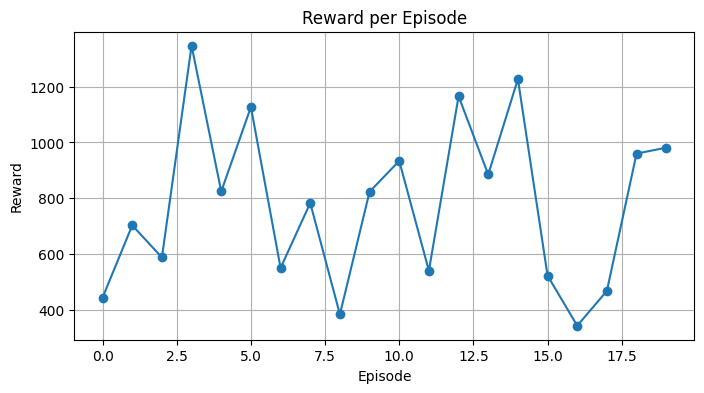

In [30]:
import matplotlib.pyplot as plt

# Define the calculate_reward function to fix the NameError
def calculate_reward(demand, price):
    # This is a placeholder reward function. You might want to define a more
    # complex and realistic reward calculation based on your environment's logic.
    # For example, revenue minus some cost, or a function of demand, price, and inventory.
    return demand * price / 100  # Example: revenue scaled down

rewards = []

for i in range(20):

    demand = np.random.randint(30,100)

    price = np.random.randint(800,1500)

    rewards.append(
        calculate_reward(
            demand,
            price
        )
    )

plt.figure(figsize=(8,4))
plt.plot(rewards, marker="o")
plt.title("Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()